In [1]:
import sys
import decode
import decode.utils
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import h5py
import scipy.ndimage as ndi
import os

def l1norm(a):
    """
    L1 norm.
    """
    asu = a - np.min(a)
    norm = np.sum(asu)
    if norm == 0:
        return np.zeros_like(a)
    return asu/norm

def upscale_and_round_to_grid(x, y):
    #these values are here to compensate systematic shift and warp of the DECODE
    # kappa = 1
    # xnear = int(np.round(x*4*kappa)+1.5) + 1 
    # ynear = int(np.round(y*4*kappa)+1.5) + 1
    kappa = 60/59.75
    xnear = int(np.round(x*4*kappa)+1.5) + 1
    ynear = int(np.round(y*4*kappa)+1.5) + 2    
    return ynear, xnear  
    
def generate_decode_image(decode_xyi, h, w, shift_foo):    
    """
    Generates a 2D image from a storm table by mapping localizations to pixel coordinates.

    Parameters:
        decode_xyi ... TODO
        h (int): Height of the output image in pixels.
        w (int): Width of the output image in pixels.

    Returns:
        numpy.ndarray: A 2D array of shape (h, w) representing the generated image, where each 
                       pixel value corresponds to the summed intensity and offset of localizations 
                       mapped to that pixel.

    Notes:
        - The function assumes a fixed scaling factor (kappa = 1/60 nm/px) to convert 
          nanometer coordinates to pixel coordinates.
        - It works with fixed upscaling factor 4x
        - Localizations are rounded to the nearest pixel using nearest-neighbor rounding.
        - If a localization falls outside the image bounds, it is ignored.
        - If multiple localizations map to the same pixel, their intensities and offsets are summed.
        - A warning message is printed if a pixel is overwritten by multiple localizations.
    """
    #"id","frame","x [nm]","y [nm]","sigma [nm]","intensity [photon]","offset [photon]","bkgstd [photon]","chi2","uncertainty [nm]"
    img = np.zeros((h,w), dtype=np.float64)
    # kappa = 1#1/60 #nm/px of object space
    #read storm table
    for x, y, intensity in decode_xyi:
        #fixed upscale factor 4 here, factor 1.5 is due to grid fitting
        xnear, ynear = shift_foo(x, y)
        if (xnear >= w) or (xnear < 0) or (ynear >= h) or (ynear < 0):
            continue
        if img[ynear, xnear] != 0:
            print("Ooops!", xnear, ynear, 'is already there')
        img[ynear, xnear] += (intensity)
    return img
    
print(f"DECODE version: {decode.utils.bookkeeping.decode_state()}")

DECODE version: 0.10.2


In [7]:
device = 'cuda:0'  # or 'cpu', or you change cuda device index
threads = 4  #  number of threads, useful for CPU heavy computation. Change if you know what you are doing.
worker = 0  # number of workers for data loading. Used a default of 0 for safety. Multiprocessing on windows is sometimes not stable

torch.set_num_threads(threads)  # set num threads

if device != 'cpu':
    if not torch.cuda.is_available():
        raise ValueError("You have selected a non CPU device, but CUDA is not available."
                         "Refer to CPU version or check your installation.")

# paths to models trained for various SNR individually
path = '../decode-model/'
path_dirs = {key : (f'gauss_snr_{key}/model_0.pt', f'gauss_snr_{key}/param_run.yaml') for key in (15, 33, 74, 126, 169, 477)}
path_dirs = {key : (os.path.join(path, itemA), os.path.join(path, itemB)) for key, (itemA, itemB) in path_dirs.items()}


def prepare_infer(path_model, path_params):
    """
    Load model and its params, prepare inference function and return it.
    """
    param = decode.utils.param_io.load_params(path_params) 
    inten = param.Simulation.intensity_mu_sig[0]
    # print(path_model, path_params)
    # print("training intesity", inten)
    camera = decode.simulation.camera.Photon2Camera.parse(param)
    model = decode.neuralfitter.models.SigmaMUNet.parse(param)
    model = decode.utils.model_io.LoadSaveModel(model,
                                                input_file=path_model,
                                                output_file=None).load_init(device=device)
    frame_proc = decode.neuralfitter.utils.processing.TransformSequence([
        decode.neuralfitter.frame_processing.AutoCenterCrop(8),
        decode.neuralfitter.scale_transform.AmplitudeRescale.parse(param)
    ])
    
    # Setup post-processing
    # It's a sequence of backscaling, relative to abs. coord conversion and frame2emitter conversion
    frames = torch.rand((3,50,50))
    size_procced = decode.neuralfitter.frame_processing.get_frame_extent(frames.unsqueeze(1).size(), frame_proc.forward)  # frame size after processing
    frame_extent = ((-0.5, size_procced[-2] - 0.5), (-0.5, size_procced[-1] - 0.5))    
    
    post_proc = decode.neuralfitter.utils.processing.TransformSequence([
        decode.neuralfitter.scale_transform.InverseParamListRescale.parse(param), #kept from the original example notebooks, scaling is taken care of elsewhere
        decode.neuralfitter.coord_transform.Offset2Coordinate(xextent=frame_extent[0],
                                                              yextent=frame_extent[1],
                                                              img_shape=size_procced[-2:]), #coordinate offset is also taken care of later, so let us keep the defaults
        decode.neuralfitter.post_processing.SpatialIntegration(raw_th=0.1,
                                                              xy_unit='px',
                                                              px_size=param.Camera.px_size) #default from the original demo notebook
    ])
    #instantiate predictor object
    infer = decode.neuralfitter.Infer(model=model, ch_in=param.HyperParameter.channels_in,
                                      frame_proc=frame_proc, post_proc=post_proc,
                                      device=device, num_workers=worker)    
    return infer

def rescale_to_training_range(img, orig_snr, orig_sigma, orig_offset):
    mxm = np.max(img)
    return (0.8*img*orig_snr*orig_sigma/mxm) + orig_offset 


def em_to_xyi(em_obj):
    xyz = em_obj.xyz
    phot = em_obj.phot
    print(len(xyz), 'em')
    xyi = np.zeros((xyz.shape[0], 3))
    xyi[:,0:2] = xyz[:,0:2]
    xyi[:,2] = phot
    xyi[:,0] += 0.5
    xyi[:,1] += 0.5
    return xyi
    
def infer_single_frame(img, infer, orig_snr, ref_range, orig_sigma = 25, orig_offset = 125):
    img2 = rescale_to_training_range(img, orig_snr, orig_sigma, orig_offset)
    #rescale input image to the range of the reference training image to ensure constitence with the training
    omxm, omnm = ref_range
    img2 -= np.min(img2)
    img2 *= (omxm-omnm)/(np.max(img2))
    img2 += omnm    
    frames = torch.from_numpy(img2.astype(np.float32).reshape((1,50,50)))
    emset = infer.forward(frames)
    xy = em_to_xyi(emset)
    return generate_decode_image(xy, 200, 200, upscale_and_round_to_grid), xy, img2
    

In [13]:
INPUT = 'input_for_cnn_star.h5'
OUTPUT = 'decode_output_individual.h5'
info = np.load('star_truth_info.npz')
# print(info.files)
snrs = info['snrs'] 

snr_unique = snrs.reshape((-1,10))[:,0]
snr_decode = np.array([key for key in path_dirs.keys()])

#indices of SNRs (selecting elements of snr_unique) that we trained DECODE for
dset_indices = [np.argmin((snr_d - snr_unique)**2) for snr_d in snr_decode]
# print(dset_indices)
# print(np.round(snr_unique[dset_indices]))
# print(np.round(snr_decode))

with h5py.File(INPUT, 'r') as h5fi:
    dset_key = 'star_vs_snr'
    img_in = np.array(h5fi[dset_key])


../decode-model/gauss_snr_15/model_0.pt ../decode-model/gauss_snr_15/param_run.yaml
training intesity 7629
Model instantiated.
Model SHA-1 hash: ef1fe3a359e4cef0bb143e3870ea19af50a7eec9
Loaded pretrained model: ../decode-model/gauss_snr_15/model_0.pt
[15.84893192]
-------- 15.848931924611133 ----------


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 74.97it/s]


25 em


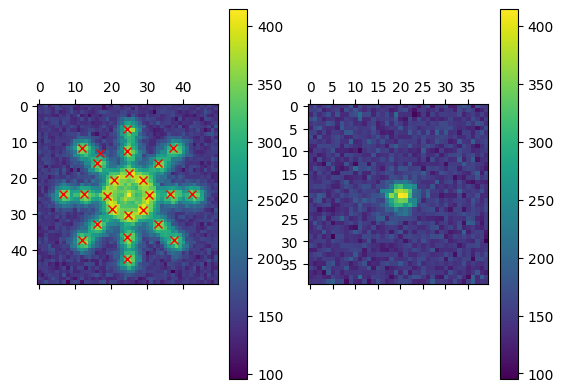

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.90it/s]


26 em


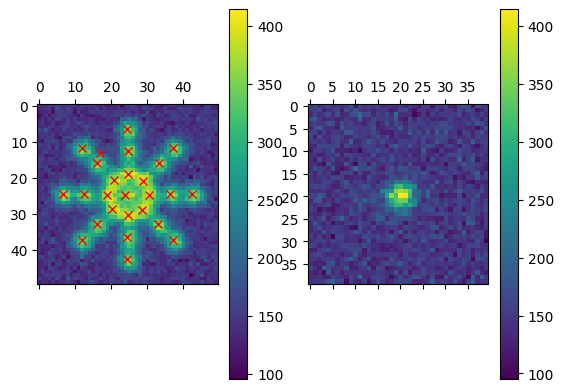

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.85it/s]


24 em


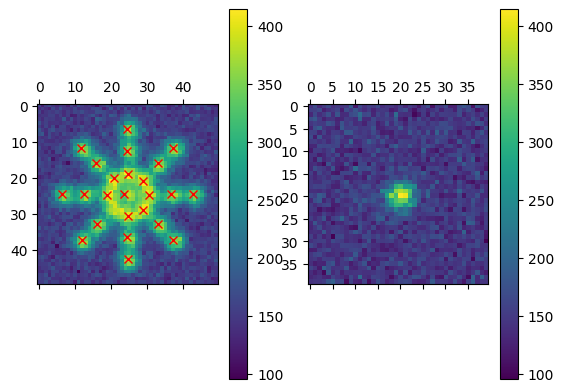

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 87.31it/s]


26 em


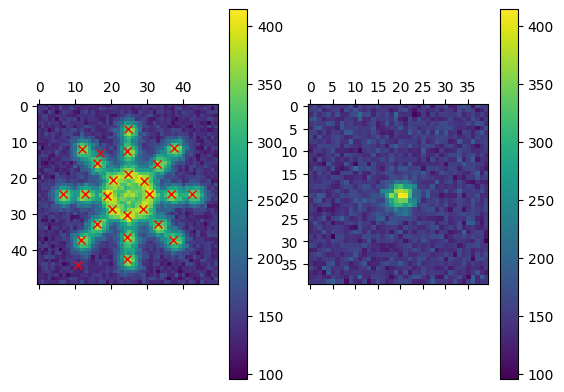

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 87.23it/s]


26 em


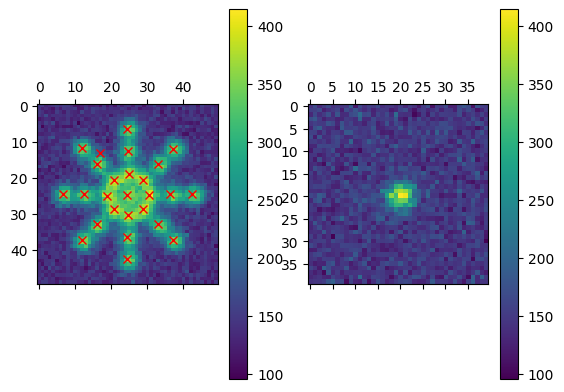

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.80it/s]


27 em


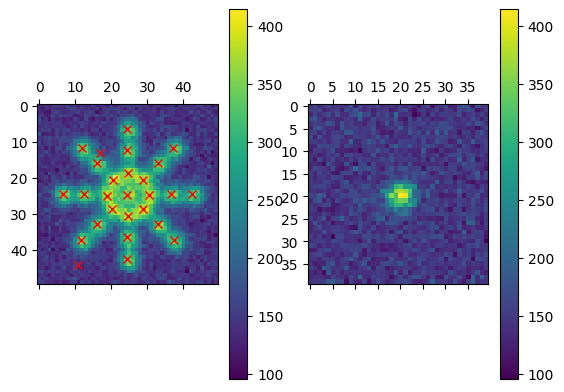

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.95it/s]


27 em


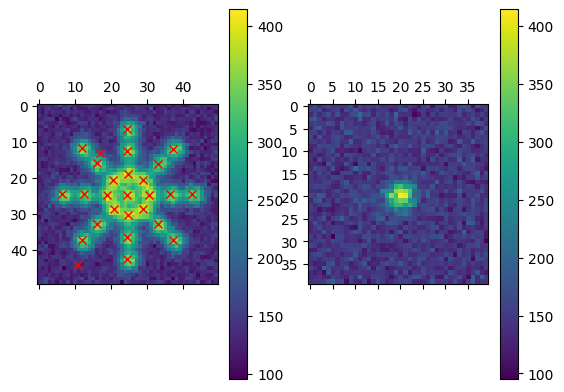

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.84it/s]


26 em


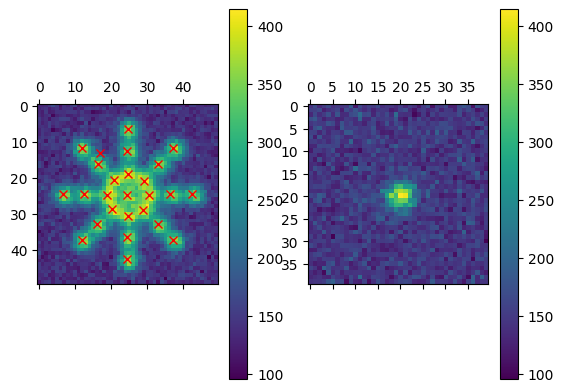

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 87.04it/s]


27 em


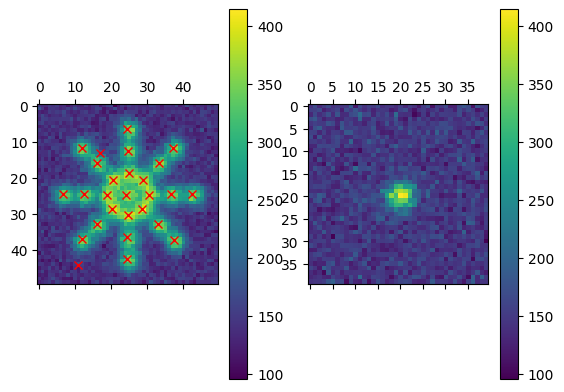

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.91it/s]


27 em


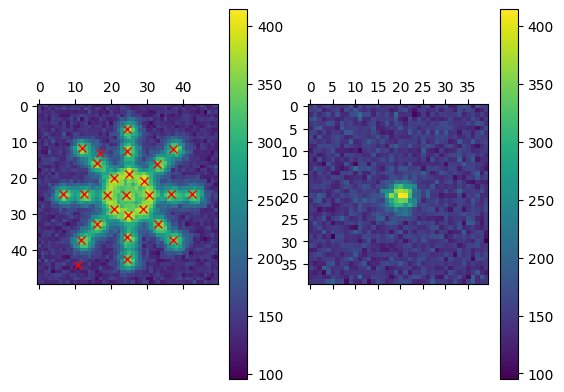

../decode-model/gauss_snr_33/model_0.pt ../decode-model/gauss_snr_33/param_run.yaml
training intesity 15310
Model instantiated.
Model SHA-1 hash: 04221194bb5020d90cd889d9f1981b4b48afce14
Loaded pretrained model: ../decode-model/gauss_snr_33/model_0.pt
[31.6227766]
-------- 31.622776601683793 ----------


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.68it/s]


22 em


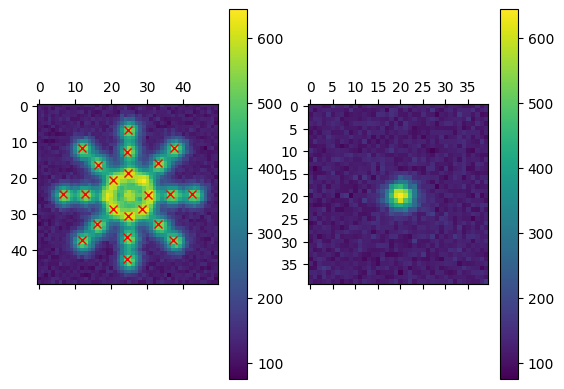

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 87.03it/s]


23 em


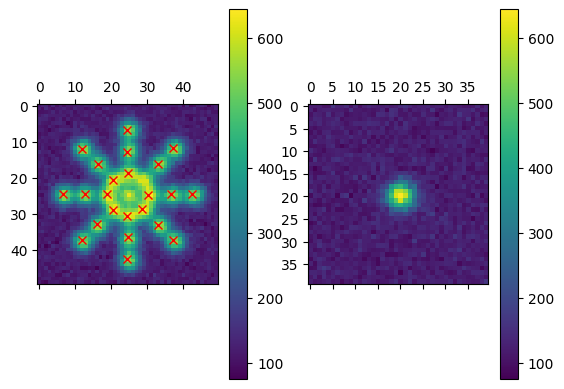

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.85it/s]


24 em


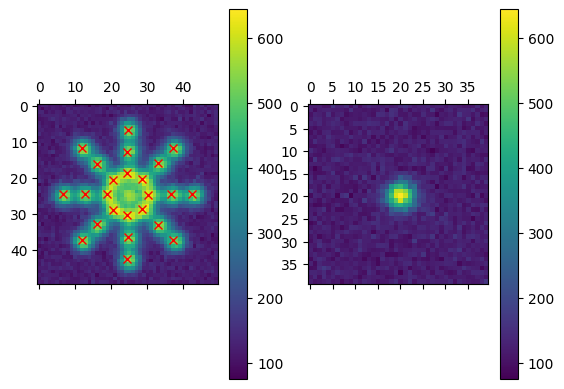

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 77.15it/s]


24 em


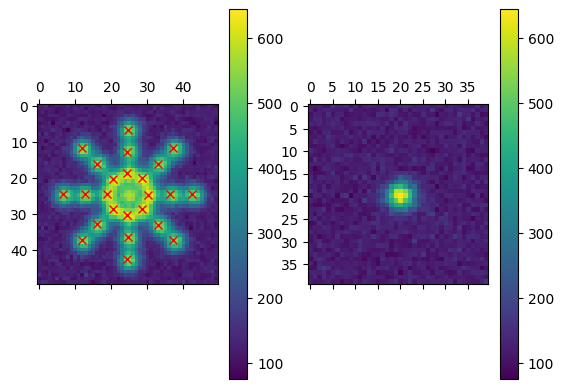

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.89it/s]


23 em


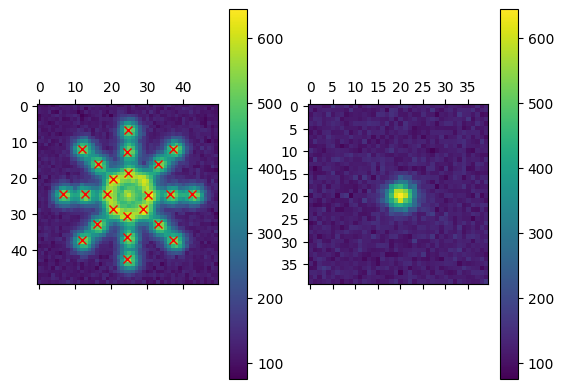

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.82it/s]


24 em


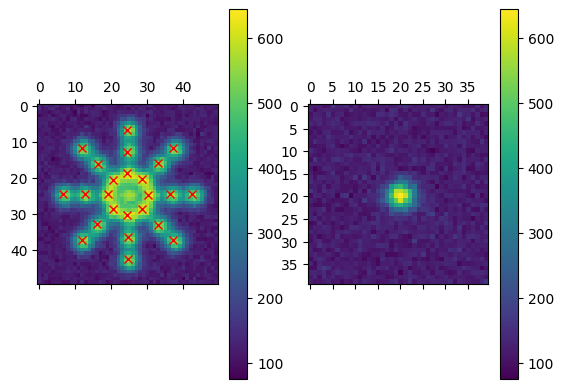

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.13it/s]


22 em


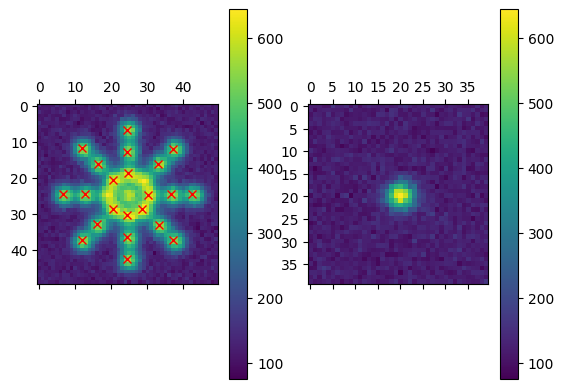

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 85.79it/s]


24 em


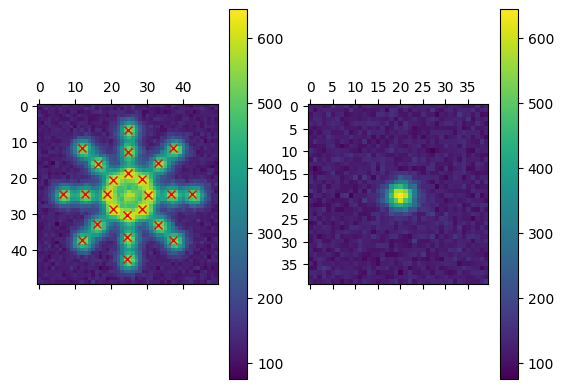

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.19it/s]


23 em


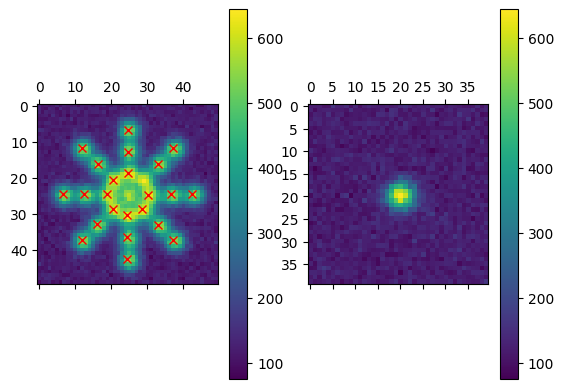

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.51it/s]


23 em


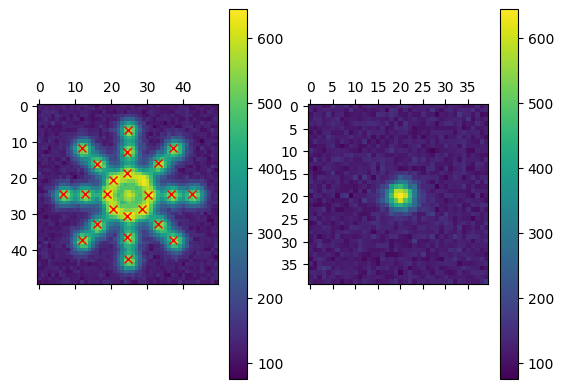

../decode-model/gauss_snr_74/model_0.pt ../decode-model/gauss_snr_74/param_run.yaml
training intesity 30725
Model instantiated.
Model SHA-1 hash: 43c36f98c6e2037bdb5c34dcfe4bd335ebc80c93
Loaded pretrained model: ../decode-model/gauss_snr_74/model_0.pt
[63.09573445]
-------- 63.0957344480193 ----------


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.41it/s]


25 em


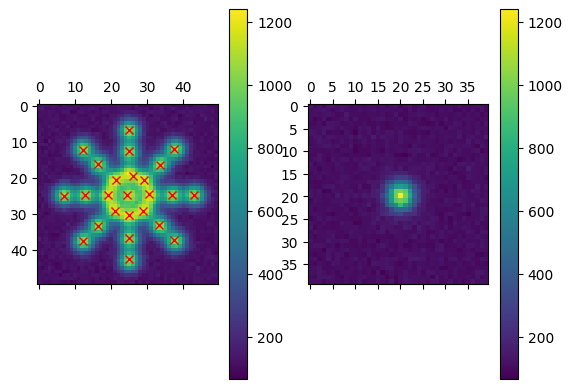

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.70it/s]


25 em


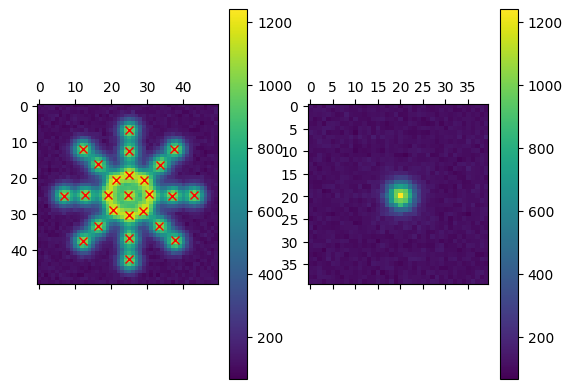

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.99it/s]


25 em


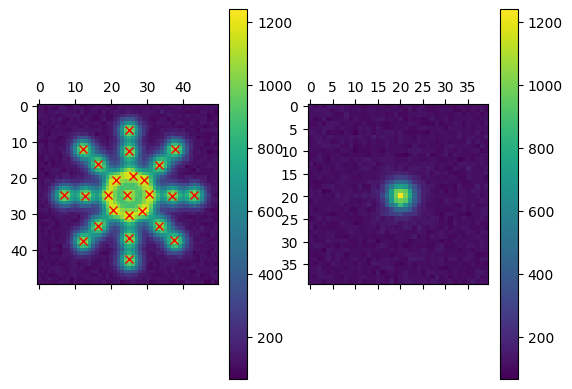

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.91it/s]


25 em


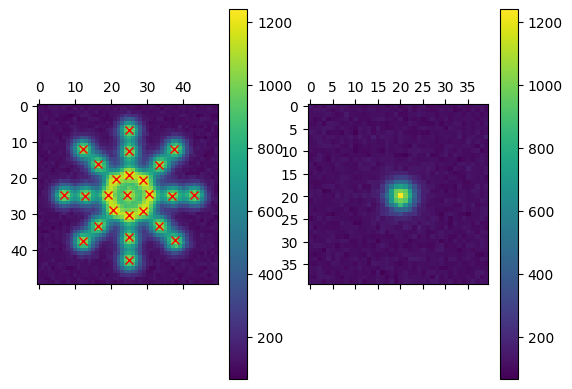

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.69it/s]


25 em


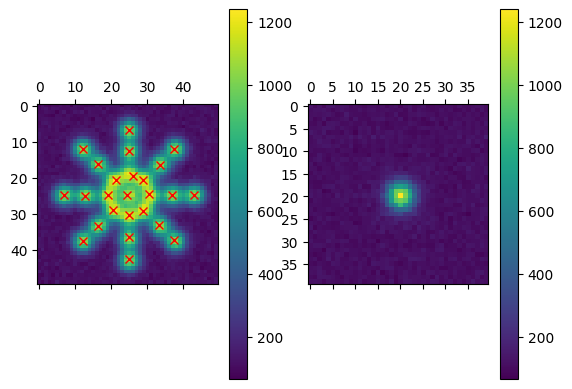

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.86it/s]


25 em


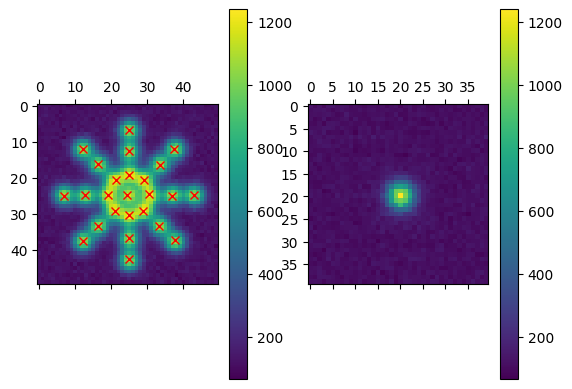

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 73.83it/s]


25 em


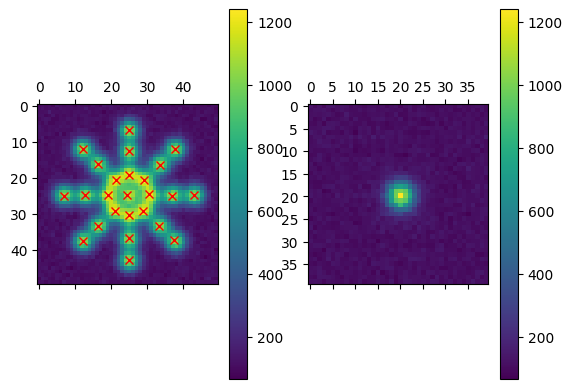

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 85.19it/s]


25 em


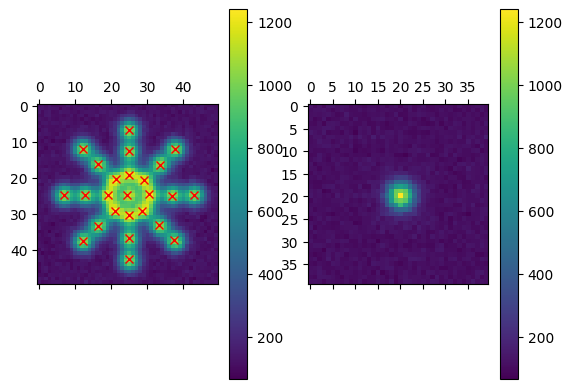

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.82it/s]


25 em


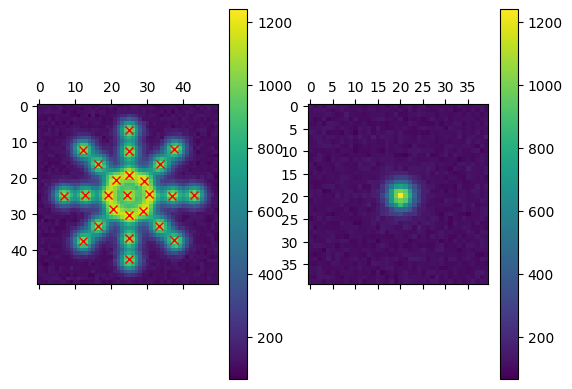

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.73it/s]


25 em


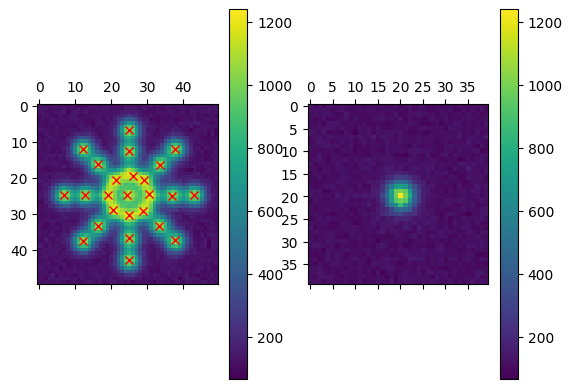

../decode-model/gauss_snr_126/model_0.pt ../decode-model/gauss_snr_126/param_run.yaml
training intesity 61659
Model instantiated.
Model SHA-1 hash: 093378f951e6970fc5f2b82597dcd18f2e4a850a
Loaded pretrained model: ../decode-model/gauss_snr_126/model_0.pt
[125.89254118]
-------- 125.89254117941675 ----------


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 83.97it/s]


23 em


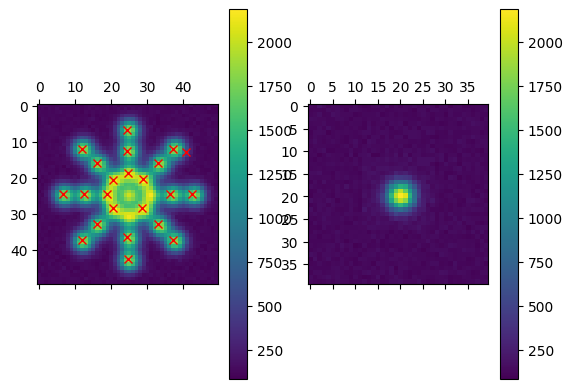

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 87.03it/s]


23 em


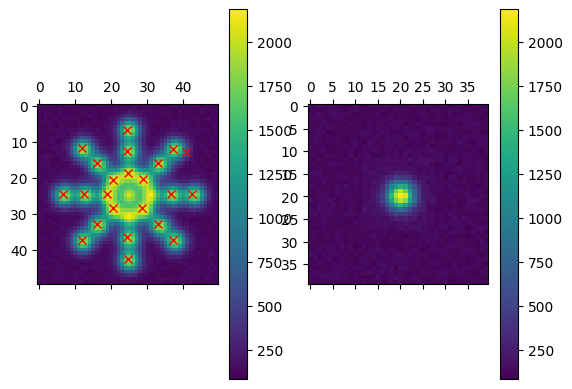

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 88.61it/s]


23 em


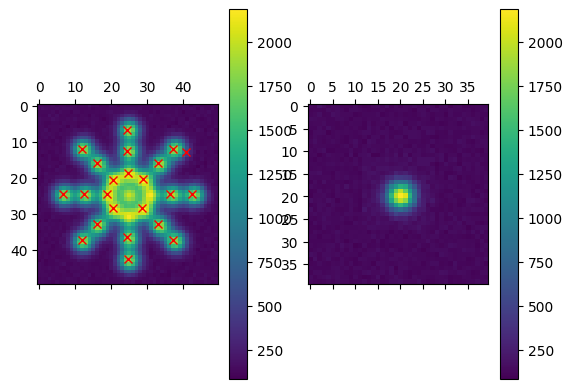

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.83it/s]


23 em


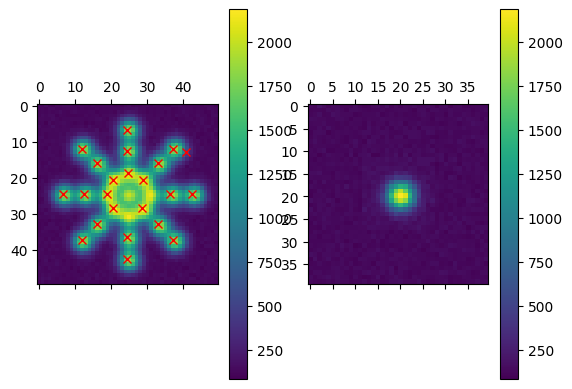

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.76it/s]


23 em


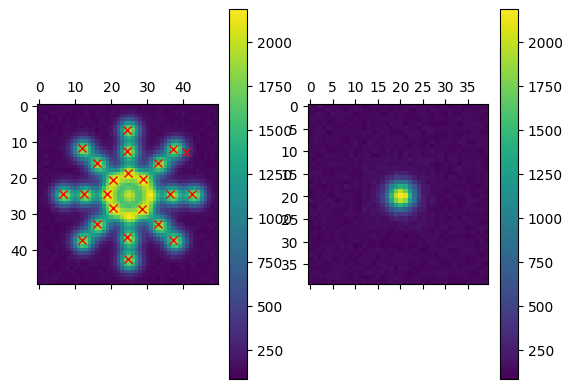

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 85.17it/s]


23 em


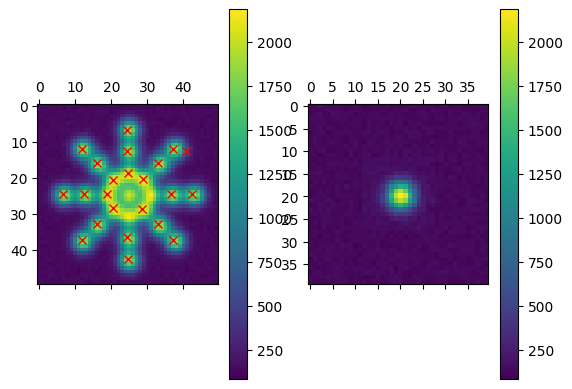

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.68it/s]


23 em


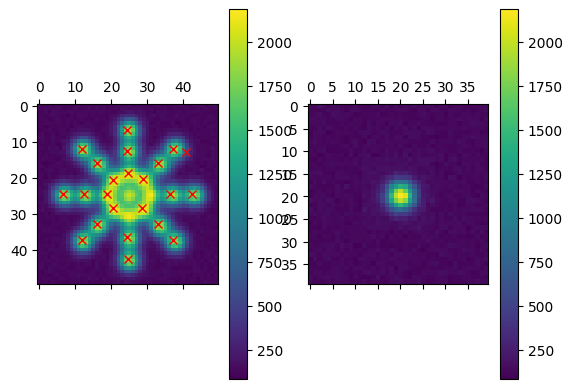

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 84.51it/s]


23 em


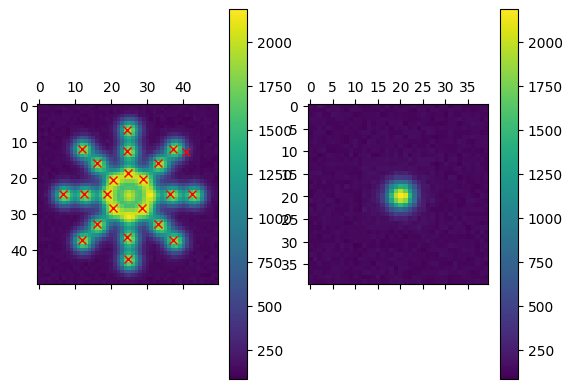

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 84.31it/s]


23 em


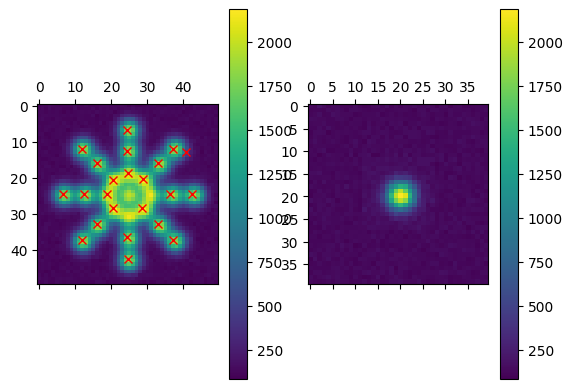

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 87.28it/s]


23 em


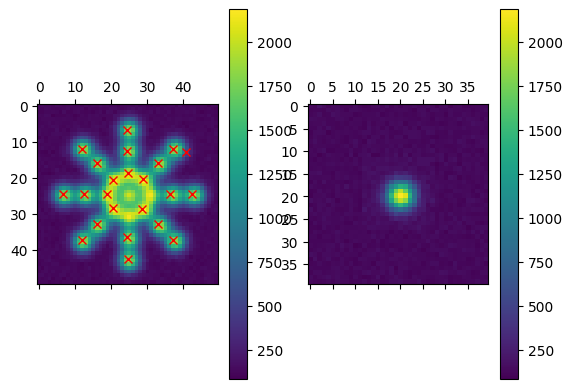

../decode-model/gauss_snr_169/model_0.pt ../decode-model/gauss_snr_169/param_run.yaml
training intesity 102329
Model instantiated.
Model SHA-1 hash: 61817807ce73d89b65a053b890e9d140ee458b55
Loaded pretrained model: ../decode-model/gauss_snr_169/model_0.pt
[125.89254118]
-------- 125.89254117941675 ----------


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 84.81it/s]


18 em


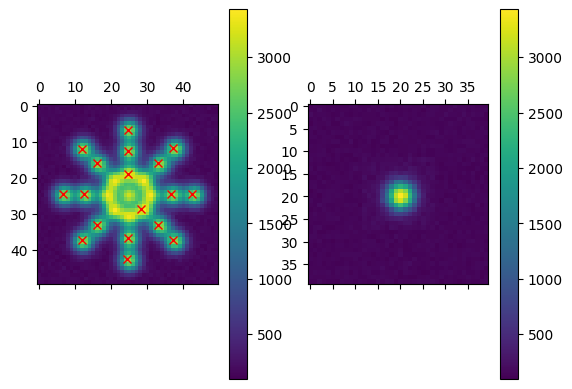

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 87.89it/s]


18 em


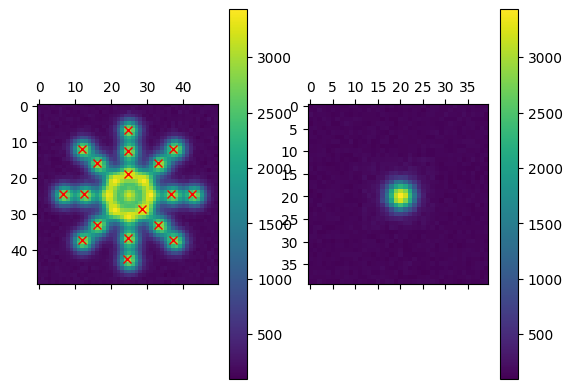

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.94it/s]


18 em


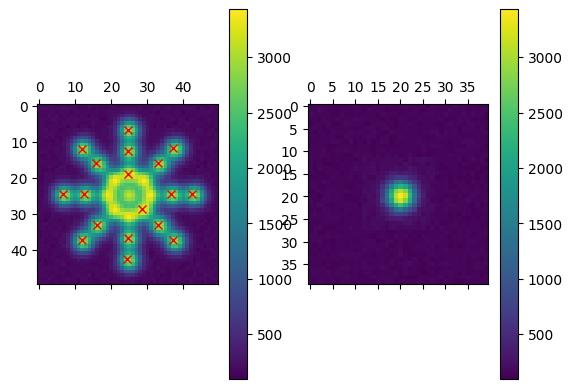

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 85.04it/s]


18 em


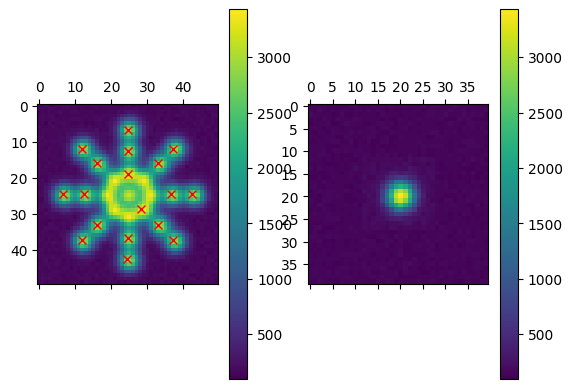

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.85it/s]


18 em


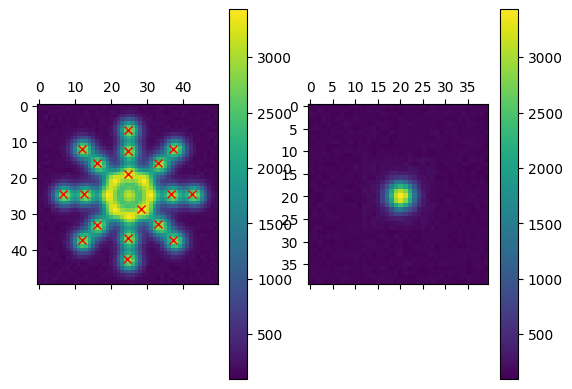

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.93it/s]


18 em


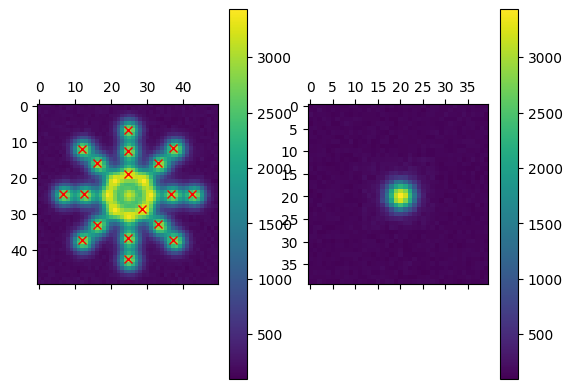

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.13it/s]


18 em


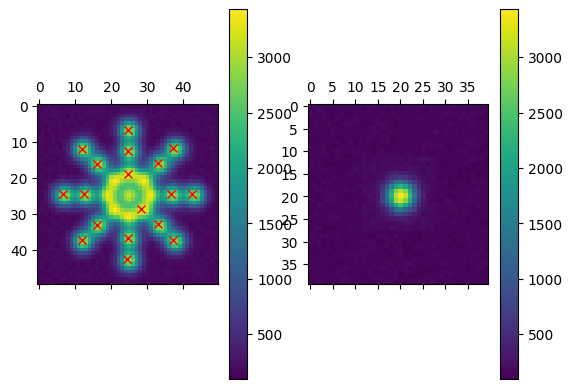

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.84it/s]


18 em


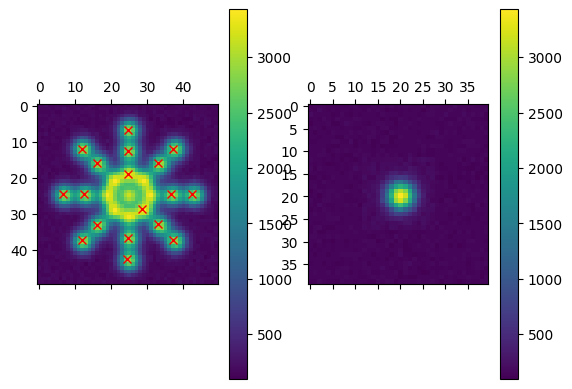

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 87.17it/s]


18 em


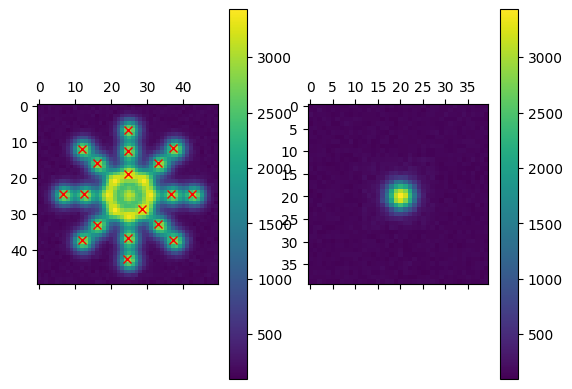

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 85.49it/s]


19 em


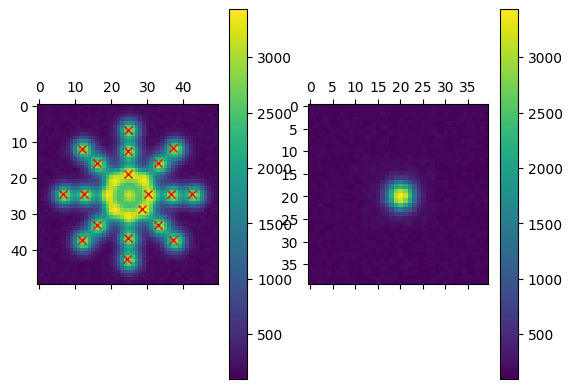

../decode-model/gauss_snr_477/model_0.pt ../decode-model/gauss_snr_477/param_run.yaml
training intesity 248313
Model instantiated.
Model SHA-1 hash: cd1e5852de41c82f1349811636d35cedf1de2424
Loaded pretrained model: ../decode-model/gauss_snr_477/model_0.pt
[501.18723363]
-------- 501.18723362727195 ----------


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.75it/s]


22 em


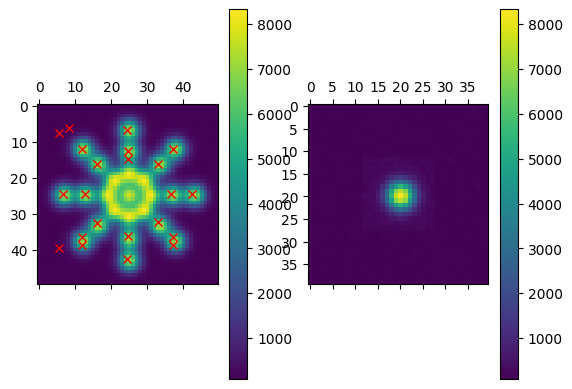

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.65it/s]


22 em


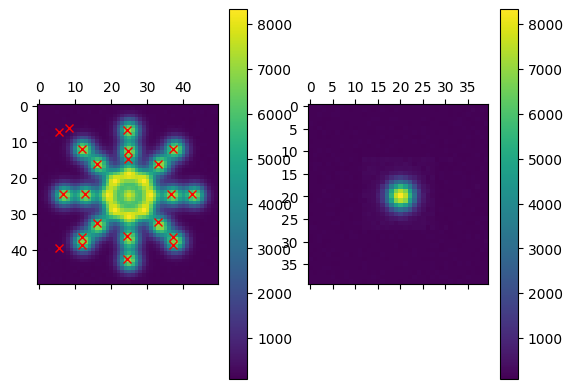

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.95it/s]


22 em


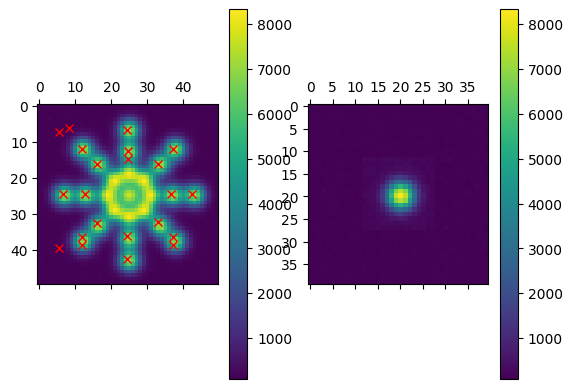

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.85it/s]


20 em


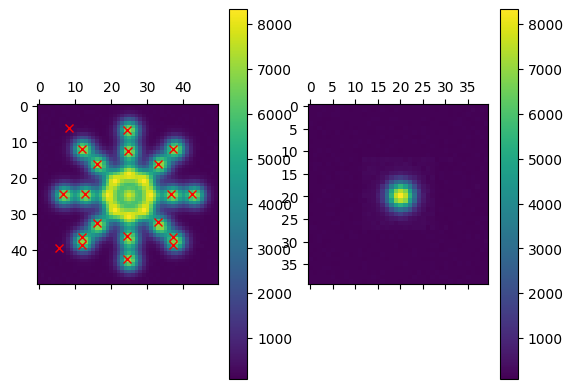

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 85.53it/s]


22 em


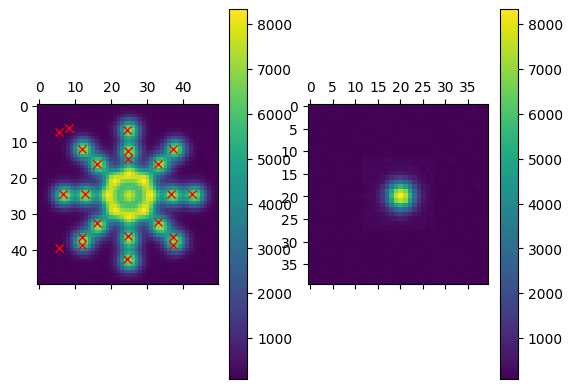

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 85.28it/s]


22 em


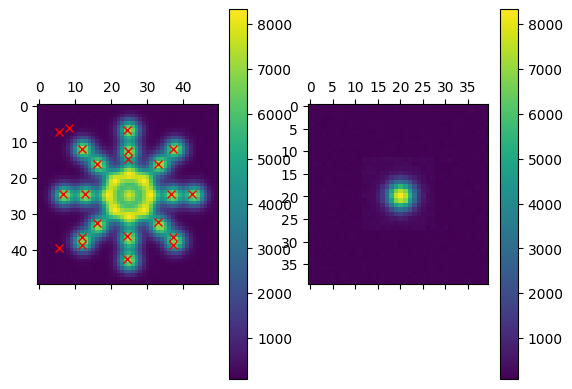

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.82it/s]


21 em


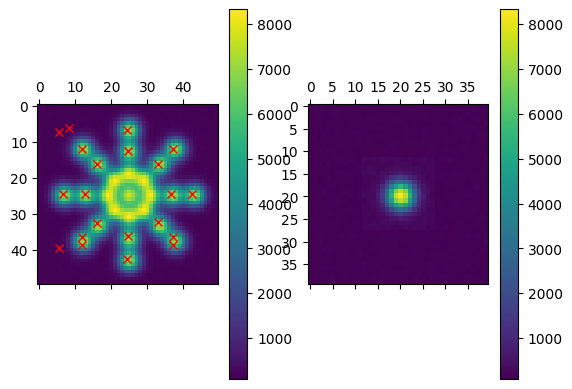

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 84.30it/s]


20 em


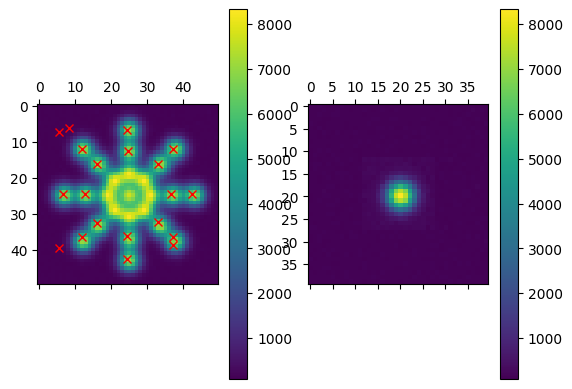

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.95it/s]


22 em


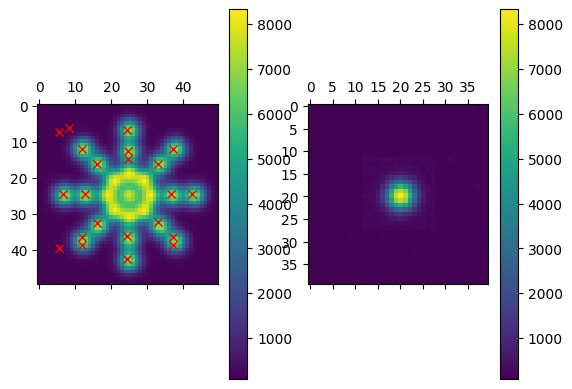

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 85.76it/s]


22 em


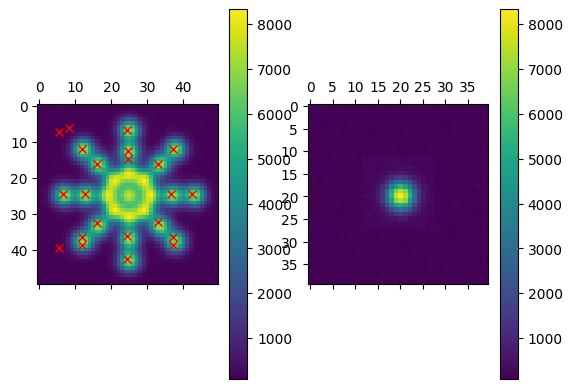

In [11]:
# snr_map = {20 : 20, 50 : 50, 200 : 75, 300 : 150, 500 : 300}

with h5py.File(OUTPUT, 'w') as h5fo:
    dset_decode = h5fo.create_dataset('star_vs_snr', (len(snr_decode)*10, 200, 200), dtype=np.float32)
    dset_decode.attrs.create('snrs', np.kron(snr_decode, np.ones(10)))
    dset_decode.attrs.create('snr_indices_to_orig', dset_indices)
    
    for i, (idx, key) in enumerate(zip(dset_indices, snr_decode)):
        infie = prepare_infer(*path_dirs[key])
        snr = snr_unique[idx] #float(snr_map[key][1])
        imgs = img_in[idx*10:idx*10 + 10]
        reference_image = np.load(os.path.join(path, 'gauss_training_reference_single_em', f'test_img_{int(key)}.npy'))
        ref_range = (np.max(reference_image), np.min(reference_image))
        print(snrs[idx*10:idx*10 + 1])
    
        print(f'-------- {snr} ----------')
        xys = []
        dimgs = []
        for j, img in enumerate(imgs):
            decode_img, xy, rimg = infer_single_frame(img, infie, snr, ref_range, orig_sigma = 25, orig_offset = 100)
            normed_decode_img = l1norm(decode_img)
            dset_decode[10*i+j, :, :] = normed_decode_img            
            dimgs.append(decode_img)
            xys.append(xy)
            fig, ax = plt.subplots(1,2)
            im1 = ax[0].matshow(rimg)
            im2 = ax[1].matshow(reference_image)
            ax[0].plot(xy[:,0],xy[:,1], 'rx')
            fig.colorbar(im1, ax=ax[0])
            fig.colorbar(im2, ax=ax[1])
            plt.show()
            
        # x = infer_single_frame(img, infie, orig_snr, orig_sigma = 25, orig_offset = 125)
    

In [14]:
with h5py.File('star_reference.h5') as h5f:
    refdata = np.array(h5f['star_vs_snr'])

with h5py.File('decode_output_individual.h5', 'r') as h5f:
    decodedata = np.array(h5f['star_vs_snr']).reshape((-1,200,200))
    decode_snr_idx = np.array(h5f['star_vs_snr'].attrs['snr_indices_to_orig'])
